In [2]:
import pandas as pd

df = pd.read_csv('2025_Airbnb_NYC_listings.csv')
df

,Unnamed: 0,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",...,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",...,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",...,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",...,4.96,4.79,4.82,OSE-STRREG-0000476,f,1,1,0,0,1.36
4,4,39282,city scrape,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,THE NEIGHBORHOOD:<br />Our apartment is locate...,168525,Gustavo,2010-07-16,"New York, NY",...,4.88,4.85,4.78,OSE-STRREG-0001150,f,2,0,2,0,1.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22303,37429,1366333532374850165,city scrape,Beautiful 1-Bed Apt in Harlem!,Welcome to your temporary home in the vibrant ...,NaN,40019013,Cecilia,2015-07-30,"New York, NY",...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
22304,37430,1366717321390111215,city scrape,Private Room w/ Ensuite Bath H,Stylish Private Rooms w/ En-Suite Baths in Bro...,NaN,483056418,Kristina,2022-10-10,"New York, NY",...,NaN,NaN,NaN,NaN,f,24,0,24,0,NaN
22305,37431,1366721904709517353,city scrape,2 Bedroom on East Side,Located in the Murray Hill area and occupies a...,NaN,30283594,Global Luxury Suites,2015-03-30,"Hawthorne, NJ",...,NaN,NaN,NaN,NaN,f,48,48,0,0,NaN
22306,37432,1366722692755341871,city scrape,Stylish 2Bd near Bryant Park,Enjoy everything the city has to offer while l...,NaN,407304997,Boomerang,2021-06-15,"New York, NY",...,NaN,NaN,NaN,NaN,t,25,25,0,0,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Unnamed: 0                                    22308 non-null  int64  
 1   id                                            22308 non-null  int64  
 2   source                                        22308 non-null  str    
 3   name                                          22308 non-null  str    
 4   description                                   21903 non-null  str    
 5   neighborhood_overview                         12262 non-null  str    
 6   host_id                                       22308 non-null  int64  
 7   host_name                                     22288 non-null  str    
 8   host_since                                    22288 non-null  str    
 9   host_location                                 17025 non-null  str    
 1

In [4]:
# 결측치 확인
df.isna().sum()


Unnamed: 0                                         0
id                                                 0
source                                             0
name                                               0
description                                      405
                                                ... 
calculated_host_listings_count                     0
calculated_host_listings_count_entire_homes        0
calculated_host_listings_count_private_rooms       0
calculated_host_listings_count_shared_rooms        0
reviews_per_month                               6798
Length: 73, dtype: int64

In [5]:
# 주요컬럼 선택
selected_cols = [
    'host_name',
    'name',
    'room_type',
    'neighbourhood_group_cleansed',
    'price',
    'number_of_reviews',
    'review_scores_rating'
]

data = df[selected_cols].copy()

# 한글 컬럼명 변경
data.columns = ['호스트', '숙소명', '숙소유형', '위치(구)', '가격', '리뷰수', '평점']

# 가격 숫자형 변환
data['가격'] = (
    data['가격']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

display(data.head())

,호스트,숙소명,숙소유형,위치(구),가격,리뷰수,평점
0,Michael,Lg Rm in Historic Prospect Heights,Private room,Brooklyn,200.0,9,4.88
1,Irene,"1 Bedroom & your own Bathroom, Elevator Apartment",Private room,Manhattan,82.0,102,4.77
2,Sarah,Luxury Brownstone in Boerum Hill,Private room,Brooklyn,765.0,43,4.70
3,Matthew,Spectacular West Harlem Garden Apt,Entire home/apt,Manhattan,139.0,241,4.85
4,Gustavo,“Work-from-home” from OUR home.,Private room,Brooklyn,130.0,274,4.82


In [6]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   호스트     22288 non-null  str    
 1   숙소명     22308 non-null  str    
 2   숙소유형    22308 non-null  str    
 3   위치(구)   22308 non-null  str    
 4   가격      22308 non-null  float64
 5   리뷰수     22308 non-null  int64  
 6   평점      15510 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 1.2 MB


,가격,리뷰수,평점
count,22308.000000,22308.000000,15510.000000
mean,213.835216,34.353102,4.724384
std,427.599435,76.783685,0.457137
min,7.000000,0.000000,1.000000
25%,85.000000,0.000000,4.662500
50%,140.000000,5.000000,4.850000
75%,240.000000,35.000000,5.000000
max,20000.000000,2749.000000,5.000000


In [7]:
data.isnull().sum()
data.duplicated().sum()

np.int64(133)

In [8]:
data[data['평점'].isnull()]

,호스트,숙소명,숙소유형,위치(구),가격,리뷰수,평점
31,L,Room in Beautiful Townhouse.,Private room,Bronx,60.0,0,NaN
59,Douglas,Beautiful Uptown Manhattan apartmnt,Private room,Manhattan,172.0,0,NaN
107,Carol Gloria,LL3,Private room,Bronx,107.0,0,NaN
110,Jeffrey,Very close to Downtown Awesome Private Apartment,Entire home/apt,Brooklyn,231.0,0,NaN
189,Sahr,The Brooklyn Waverly,Entire home/apt,Brooklyn,800.0,0,NaN
...,...,...,...,...,...,...,...
22303,Cecilia,Beautiful 1-Bed Apt in Harlem!,Private room,Manhattan,72.0,0,NaN
22304,Kristina,Private Room w/ Ensuite Bath H,Private room,Brooklyn,58.0,0,NaN
22305,Global Luxury Suites,2 Bedroom on East Side,Entire home/apt,Manhattan,299.0,0,NaN
22306,Boomerang,Stylish 2Bd near Bryant Park,Entire home/apt,Manhattan,200.0,0,NaN


In [11]:
df.columns

Index(['Unnamed: 0', 'id', 'source', 'name', 'description',
       'neighborhood_overview', 'host_id', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
     

- 표준편차(275)가 평균(224)보다 큼
- 최소 8달러에서 최대 9894달러까지 분포하여 동일 그룹 내 가격 편차가 매우 큼 !!  => 고가 숙소와 저가 숙소가 동시에 존재함을 의미
- 박스플롯으로 확인

In [17]:
# 숙소 수 가장 많은 지역
top_neigh = df["neighbourhood"].value_counts().idxmax()
print("가장 많은 지역:", top_neigh)

# 해당 지역 데이터만 추출
df_region = df[df["neighbourhood"] == top_neigh]

가장 많은 지역: Neighborhood highlights


In [18]:
# 유형별 평균, 표준편차
df_region.groupby("room_type")["price"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
room_type,,,,,
Entire home/apt,7380,269.369106,254.592699,39.0,5000.0
Hotel room,352,536.622159,539.299141,8.0,6563.0
Private room,4490,126.493764,239.036042,19.0,9894.0
Shared room,40,172.975000,341.182671,32.0,2025.0


<Figure size 640x480 with 0 Axes>

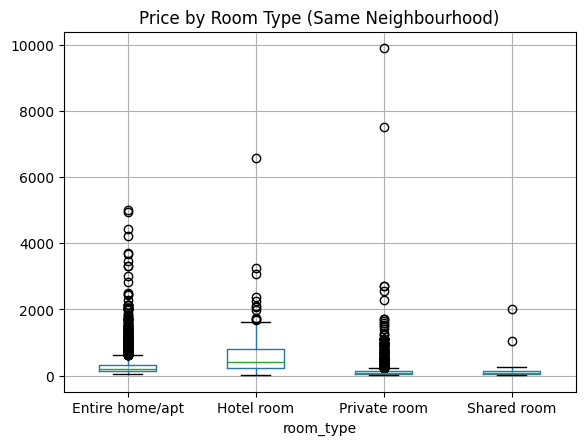

In [19]:
import matplotlib.pyplot as plt

plt.figure()
df_region.boxplot(column="price", by="room_type")
plt.suptitle("")
plt.title("Price by Room Type (Same Neighbourhood)")
plt.show()

In [22]:
# 리뷰 평균, 표준편차
df_region.groupby("number_of_reviews")["price"].agg(
    ["count", "mean", "std", "min", "max"]
)

,count,mean,std,min,max
number_of_reviews,,,,,
0,2839,354.875660,362.909031,8.0,6563.0
1,750,246.730667,245.781747,28.0,3300.0
2,486,207.508230,240.401526,24.0,3000.0
3,372,179.706989,147.500350,29.0,1082.0
4,279,198.480287,263.654284,31.0,2500.0
...,...,...,...,...,...
999,1,103.000000,NaN,103.0,103.0
1193,1,172.000000,NaN,172.0,172.0
1709,1,124.000000,NaN,124.0,124.0


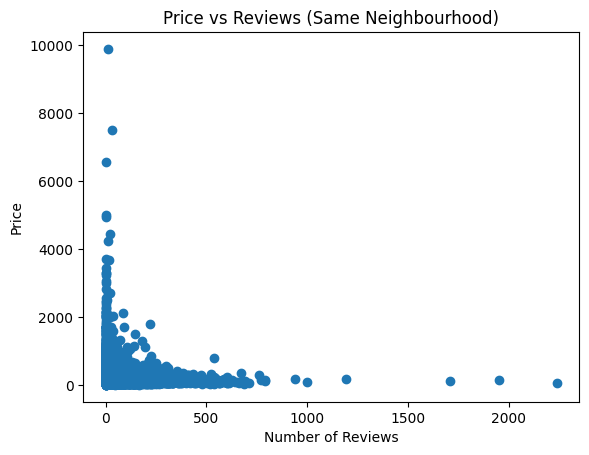

In [ ]:
# 리뷰 수에 따른 가격
plt.figure()
plt.scatter(df_region["number_of_reviews"], df_region["price"])
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.title("Price vs Reviews (Same Neighbourhood)")
plt.show()

In [21]:
Q1 = df_region["price"].quantile(0.25)
Q3 = df_region["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_region[(df_region["price"] < lower) | 
                      (df_region["price"] > upper)]

print("이상치 개수:", len(outliers))

이상치 개수: 649
